In [44]:
import pandas as pd
df=pd.read_excel("Dataset.xlsx")
df

,section,description,case study
0,300,"Murder,\nWhen culpable homicide is not murder",\nA person was attacked by an armed assailant ...
1,300,"Murder,\nWhen culpable homicide is not murder",\nTwo individuals engaged in a heated argument...
2,300,"Murder,\nWhen culpable homicide is not murder",\nA group of friends was involved in a prank w...
3,300,"Murder,\nWhen culpable homicide is not murder","\nDuring a medical procedure or surgery, a sur..."
4,300,"Murder,\nWhen culpable homicide is not murder",Accidental Discharge of a Firearm:\nIn a case ...
...,...,...,...
640,420,Cheating and Dishonestly Inducing Delivery of ...,An individual advertised products for sale on...
641,420,Cheating and Dishonestly Inducing Delivery of ...,A group of individuals convinced victims to in...
642,420,Cheating and Dishonestly Inducing Delivery of ...,Fraudsters used deceptive tactics to obtain pa...
643,420,Cheating and Dishonestly Inducing Delivery of ...,Cybercriminals gained access to victims' inte...


In [45]:
df.isnull().sum()

section        0
description    0
case study     0
dtype: int64

In [46]:
df["case study"] = df['description'].astype(str) +" "+ df["case study"].astype(str)
df

,section,description,case study
0,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
1,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
2,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
3,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
4,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ..."
...,...,...,...
640,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...
641,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...
642,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...
643,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...


In [47]:
df.section.unique()

array([300, 301, 302, 303, 304, '304A', '304B', 305, 307, 308, 310, 319,
       320, 321, 322, 323, 324, 325, 326, '326A', '326B', 327, 328, 329,
       330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342,
       343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, '354A',
       '354B', '354C', '354D', 355, 356, 357, 358, 359, 360, 361, 362,
       363, '363A', 364, '364A', 365, 366, '366A', '366B', 367, 368, 369,
       370, '370A', 371, 372, 373, 374, 375, 376, '376A', '376B', '376C',
       '376D', '376E', 377, 378, 379, 380, 381, 382, 383, 384, 385, 386,
       387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399,
       400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412,
       413, 414, 415, 416, 417, 418, 419, 420], dtype=object)

In [48]:
df.section.nunique()

129

In [49]:
import nltk 
def remove_stopwords(text):
    stopwords=nltk.corpus.stopwords.words('english')
    clean_text=' '.join([word for word in text.split() if word not in stopwords])
    return clean_text

from nltk.stem.porter import PorterStemmer
def cleanup_data(df):
    # remove handle
    df['clean'] = df["case study"].str.replace("@", "") 
    # remove links
    df['clean'] = df['clean'].str.replace(r"http\S+", "") 
    # remove punctuations and special characters
    df['clean'] = df['clean'].str.replace("[^a-zA-Z]", " ") 
    # remove stop words
    df['clean'] = df['clean'].apply(lambda text : remove_stopwords(text.lower()))
    # split text and tokenize
    df['clean'] = df['clean'].apply(lambda x: x.split())
    # let's apply stemmer
    stemmer = PorterStemmer()
    df['clean'] = df['clean'].apply(lambda x: [stemmer.stem(i) for i in x])
    # stitch back words
    df['clean'] = df['clean'].apply(lambda x: ' '.join([w for w in x]))
    # remove small words
    df['clean'] = df['clean'].apply(lambda x: ' '.join([w for w in x.split() if len(w)>3]))
cleanup_data(df)
df

,section,description,case study,clean
0,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...",murder culpabl homicid murder person attack as...
1,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...",murder culpabl homicid murder individu engag h...
2,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...",murder culpabl homicid murder group friend inv...
3,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...",murder culpabl homicid murder medic procedur s...
4,300,"Murder,\nWhen culpable homicide is not murder","Murder,\nWhen culpable homicide is not murder ...",murder culpabl homicid murder accident dischar...
...,...,...,...,...
640,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...,cheat dishonestli induc deliveri properti indi...
641,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...,cheat dishonestli induc deliveri properti grou...
642,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...,cheat dishonestli induc deliveri properti frau...
643,420,Cheating and Dishonestly Inducing Delivery of ...,Cheating and Dishonestly Inducing Delivery of ...,cheat dishonestli induc deliveri properti cybe...


In [50]:
data = [x[0] for x in df[['clean']].to_records(index=False)]
labels = [x[0] for x in df[["section"]].to_records(index=False)]
from sklearn.feature_extraction.text import TfidfVectorizer
extra_params={'min_df': 0.001}
vectorizer = TfidfVectorizer(**extra_params)
# feature vectors
data_vect = vectorizer.fit_transform(data)
print(data_vect.shape)

(645, 2213)


In [51]:
vectorizer.get_feature_names_out()

array(['aarushi', 'abandon', 'abduct', ..., 'zidan', 'zinedin', 'zone'],
      dtype=object)

In [52]:
# get idf values
print('\nidf values:')
for ele1, ele2 in zip(vectorizer.get_feature_names(), vectorizer.idf_):
    print(ele1, ':', ele2)


idf values:
aarushi : 6.372187215114492
abandon : 6.084505142662711
abduct : 3.6421581072935068
abductor : 4.985892853994601
abet : 5.679040034554547
aboard : 6.777652323222656
abus : 4.426277066059178
accept : 5.861361591348501
access : 5.524889354727288
accessori : 6.777652323222656
accid : 6.372187215114492
accident : 6.372187215114492
accomplic : 5.524889354727288
account : 4.905850146321065
accus : 3.7095993880890394
acid : 4.985892853994601
acquir : 6.777652323222656
acquit : 5.391357962102766
acquitt : 6.777652323222656
across : 5.861361591348501
action : 3.5789792056719754
activ : 4.637586159726386
activist : 4.985892853994601
actor : 5.524889354727288
addit : 6.372187215114492
address : 6.777652323222656
admiss : 6.372187215114492
adopt : 6.084505142662711
adult : 6.372187215114492
advanc : 6.372187215114492
advers : 6.777652323222656
advertis : 6.777652323222656
advic : 6.777652323222656
advisor : 6.372187215114492
advoc : 5.391357962102766
advocaci : 6.372187215114492
affai

cricket : 6.372187215114492
crime : 4.379757050424287
crimin : 2.5291570811732975
crisi : 6.372187215114492
critic : 6.084505142662711
crop : 6.777652323222656
cross : 6.372187215114492
crowd : 5.391357962102766
culpabl : 4.698210781542821
culprit : 5.861361591348501
cult : 5.679040034554547
cultur : 6.777652323222656
currenc : 6.777652323222656
custodi : 5.679040034554547
custom : 4.292745673434656
cutoff : 6.777652323222656
cyanid : 6.777652323222656
cyberbulli : 6.777652323222656
cybercrim : 6.372187215114492
cybercrimin : 6.777652323222656
dabo : 6.777652323222656
dacoit : 4.580427745886437
dacoiti : 3.915451442293188
dalit : 6.777652323222656
damag : 5.391357962102766
danger : 4.831742174167344
daniel : 6.777652323222656
dare : 6.084505142662711
dark : 6.777652323222656
date : 6.372187215114492
daughter : 5.391357962102766
dave : 6.777652323222656
david : 6.372187215114492
dead : 6.777652323222656
deadli : 4.905850146321065
deadliest : 6.372187215114492
deal : 5.072904230984231
de

hundr : 6.372187215114492
hurt : 2.5956021805814506
husband : 4.762749302680392
hyderabad : 6.777652323222656
ident : 6.372187215114492
identif : 5.391357962102766
identifi : 6.084505142662711
ideolog : 6.777652323222656
iklopil : 6.777652323222656
illeg : 4.174962637778273
imag : 6.777652323222656
immedi : 6.777652323222656
immigr : 6.084505142662711
immol : 6.777652323222656
impact : 6.777652323222656
imperson : 5.391357962102766
implic : 5.861361591348501
import : 5.391357962102766
impostor : 6.777652323222656
impoverish : 6.372187215114492
imprison : 4.637586159726386
inadequ : 5.861361591348501
inappropri : 6.084505142662711
incarcer : 6.777652323222656
incid : 3.8072378576529555
includ : 3.7331298854992334
incom : 6.777652323222656
incommunicado : 6.777652323222656
indefinit : 6.777652323222656
india : 3.887280565326492
indian : 4.637586159726386
indic : 6.777652323222656
individu : 2.4668531978371426
indoctrin : 6.777652323222656
indrani : 6.777652323222656
induc : 4.98589285399

path : 6.777652323222656
patient : 5.524889354727288
patron : 5.524889354727288
patterson : 6.777652323222656
patti : 6.777652323222656
patz : 6.777652323222656
pavement : 6.777652323222656
pawnshop : 6.084505142662711
payment : 5.391357962102766
payout : 6.777652323222656
payrol : 6.777652323222656
peac : 6.777652323222656
pedestrian : 6.372187215114492
pedro : 6.777652323222656
pellet : 6.777652323222656
penal : 6.777652323222656
penalti : 6.372187215114492
peni : 6.372187215114492
penitentiari : 6.777652323222656
peopl : 4.292745673434656
percept : 6.777652323222656
perform : 6.372187215114492
perhap : 6.777652323222656
period : 5.524889354727288
perpetr : 3.664137014012282
persist : 5.391357962102766
person : 2.408204470755635
personnel : 4.831742174167344
persuad : 6.372187215114492
perugia : 6.777652323222656
peruvian : 6.777652323222656
pesticid : 6.372187215114492
phillip : 6.372187215114492
phogat : 6.777652323222656
phone : 5.679040034554547
phoolan : 6.777652323222656
photoj

situat : 6.084505142662711
skate : 6.372187215114492
skater : 6.372187215114492
slave : 5.679040034554547
slaveri : 5.679040034554547
sleep : 6.372187215114492
sleeper : 6.777652323222656
slept : 6.777652323222656
smart : 6.777652323222656
smartphon : 6.372187215114492
smith : 6.777652323222656
smuggl : 6.777652323222656
snatch : 6.084505142662711
soccer : 5.679040034554547
social : 6.084505142662711
socialit : 6.777652323222656
societ : 6.777652323222656
societi : 6.777652323222656
sold : 4.698210781542821
solitari : 6.777652323222656
solo : 6.777652323222656
someon : 5.524889354727288
sought : 6.084505142662711
south : 6.777652323222656
southeast : 6.777652323222656
space : 6.777652323222656
span : 6.777652323222656
spark : 5.524889354727288
special : 6.372187215114492
specif : 6.372187215114492
specifi : 6.777652323222656
spectat : 6.372187215114492
speed : 6.372187215114492
spent : 6.372187215114492
spill : 6.777652323222656
sport : 6.372187215114492
spous : 6.777652323222656
spous

In [53]:
print(vectorizer.vocabulary_)

{'murder': 1318, 'culpabl': 470, 'homicid': 944, 'person': 1466, 'attack': 131, 'assail': 120, 'dark': 490, 'alley': 64, 'self': 1779, 'defens': 515, 'victim': 2125, 'fought': 802, 'back': 148, 'manag': 1227, 'disarm': 559, 'howev': 959, 'struggl': 1923, 'kill': 1113, 'case': 289, 'argu': 106, 'protect': 1567, 'life': 1173, 'classifi': 344, 'individu': 994, 'engag': 652, 'heat': 913, 'argument': 107, 'escal': 670, 'sudden': 1936, 'physic': 1477, 'fight': 761, 'brawl': 226, 'deliv': 520, 'fatal': 743, 'blow': 201, 'result': 1687, 'death': 501, 'establish': 676, 'occur': 1374, 'moment': 1304, 'without': 2182, 'prior': 1538, 'intent': 1032, 'plan': 1484, 'amount': 78, 'group': 872, 'friend': 818, 'involv': 1052, 'prank': 1516, 'intend': 1030, 'scare': 1757, 'anoth': 89, 'pretend': 1529, 'harm': 898, 'went': 2163, 'horribl': 948, 'wrong': 2197, 'suffer': 1937, 'heart': 912, 'extrem': 722, 'fear': 748, 'induc': 997, 'caus': 298, 'consid': 409, 'medic': 1263, 'procedur': 1543, 'surgeri': 194

In [54]:
data_vect.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [55]:
#split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_vect, labels, test_size=0.20)
print(len(y_train), len(y_test))

516 129


K-Nearest Neighbors
              precision    recall  f1-score   support

         300       1.00      1.00      1.00         2
         301       1.00      1.00      1.00         2
         302       0.67      1.00      0.80         2
         303       1.00      1.00      1.00         1
        304B       1.00      1.00      1.00         2
         307       1.00      1.00      1.00         1
         310       1.00      1.00      1.00         3
         319       0.00      0.00      0.00         1
         321       0.75      1.00      0.86         3
         322       1.00      0.50      0.67         2
         324       0.50      1.00      0.67         1
         325       1.00      1.00      1.00         1
         326       0.00      0.00      0.00         1
         327       0.00      0.00      0.00         1
         328       1.00      1.00      1.00         1
         329       0.00      0.00      0.00         0
         330       0.00      0.00      0.00         1
       

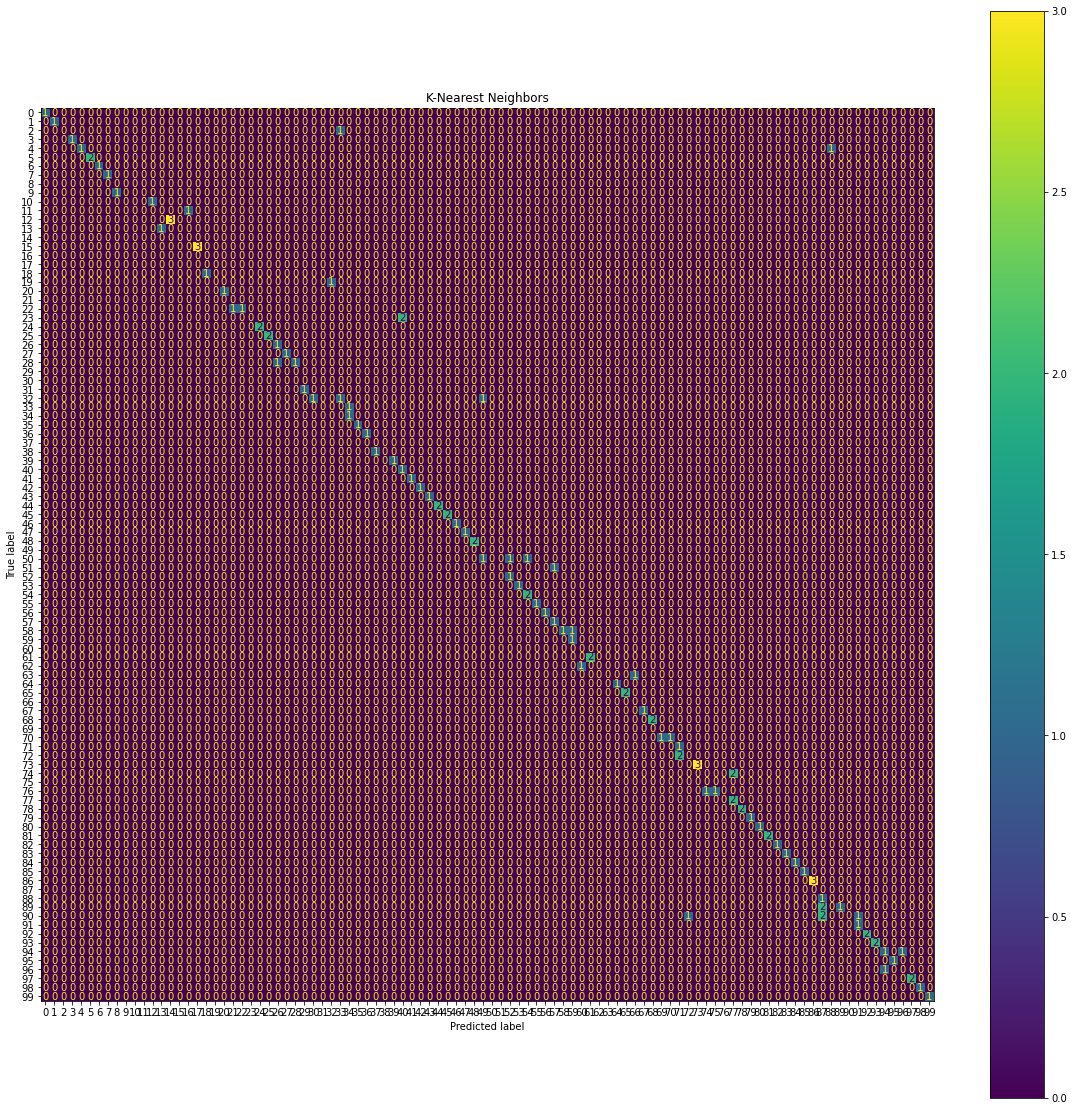

--------------------------------------------------------------
Liner SVM
              precision    recall  f1-score   support

         300       1.00      1.00      1.00         2
         301       1.00      1.00      1.00         2
         302       1.00      1.00      1.00         2
         303       1.00      1.00      1.00         1
        304B       1.00      1.00      1.00         2
         307       1.00      1.00      1.00         1
         310       1.00      1.00      1.00         3
         319       1.00      1.00      1.00         1
         321       1.00      1.00      1.00         3
         322       1.00      1.00      1.00         2
         324       1.00      1.00      1.00         1
         325       1.00      1.00      1.00         1
         326       1.00      1.00      1.00         1
         327       1.00      1.00      1.00         1
         328       1.00      1.00      1.00         1
         330       1.00      1.00      1.00         1
        

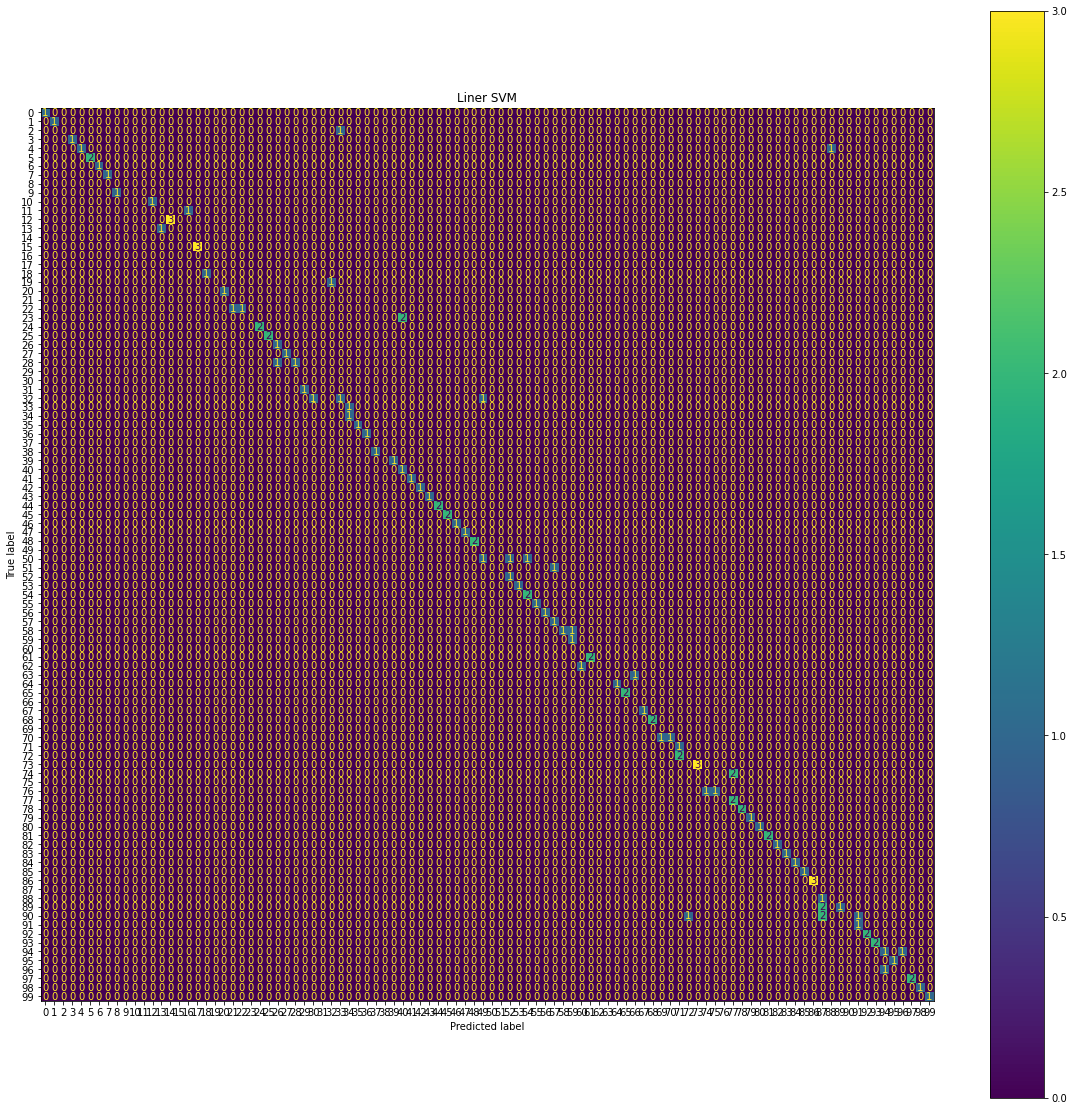

--------------------------------------------------------------
Decision Tree
              precision    recall  f1-score   support

         300       1.00      1.00      1.00         2
         301       1.00      1.00      1.00         2
         302       1.00      1.00      1.00         2
         303       1.00      1.00      1.00         1
        304B       1.00      1.00      1.00         2
         307       1.00      1.00      1.00         1
         310       1.00      1.00      1.00         3
         319       1.00      1.00      1.00         1
         321       1.00      1.00      1.00         3
         322       1.00      1.00      1.00         2
         324       1.00      1.00      1.00         1
         325       1.00      1.00      1.00         1
         326       1.00      1.00      1.00         1
         327       1.00      1.00      1.00         1
         328       1.00      1.00      1.00         1
         330       1.00      1.00      1.00         1
    

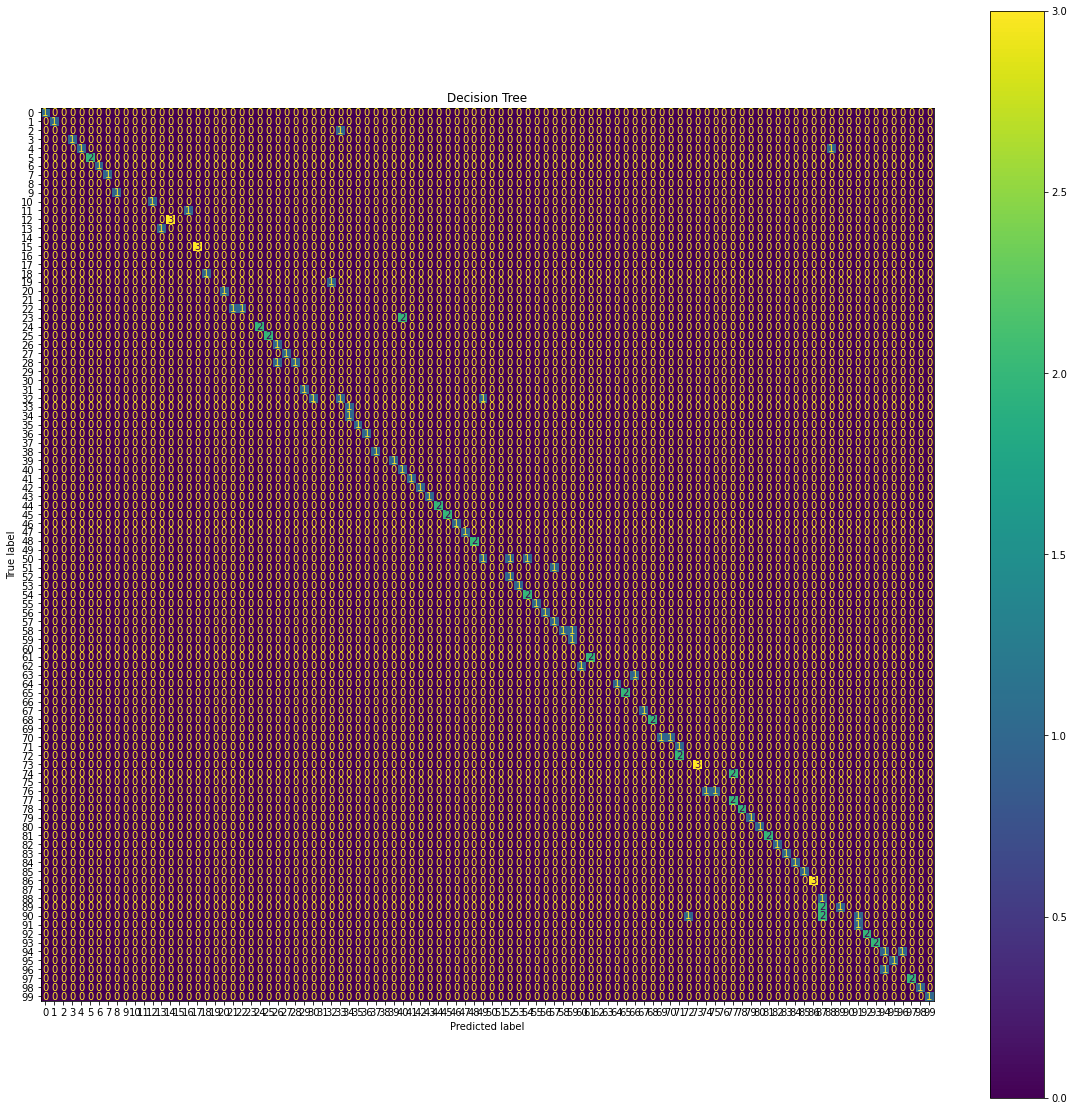

--------------------------------------------------------------
Random Forest
              precision    recall  f1-score   support

         300       1.00      1.00      1.00         2
         301       1.00      1.00      1.00         2
         302       1.00      1.00      1.00         2
         303       1.00      1.00      1.00         1
        304B       1.00      1.00      1.00         2
         307       1.00      1.00      1.00         1
         310       1.00      1.00      1.00         3
         319       1.00      1.00      1.00         1
         321       1.00      1.00      1.00         3
         322       1.00      1.00      1.00         2
         324       1.00      1.00      1.00         1
         325       1.00      1.00      1.00         1
         326       1.00      1.00      1.00         1
         327       1.00      1.00      1.00         1
         328       1.00      1.00      1.00         1
         330       1.00      1.00      1.00         1
    

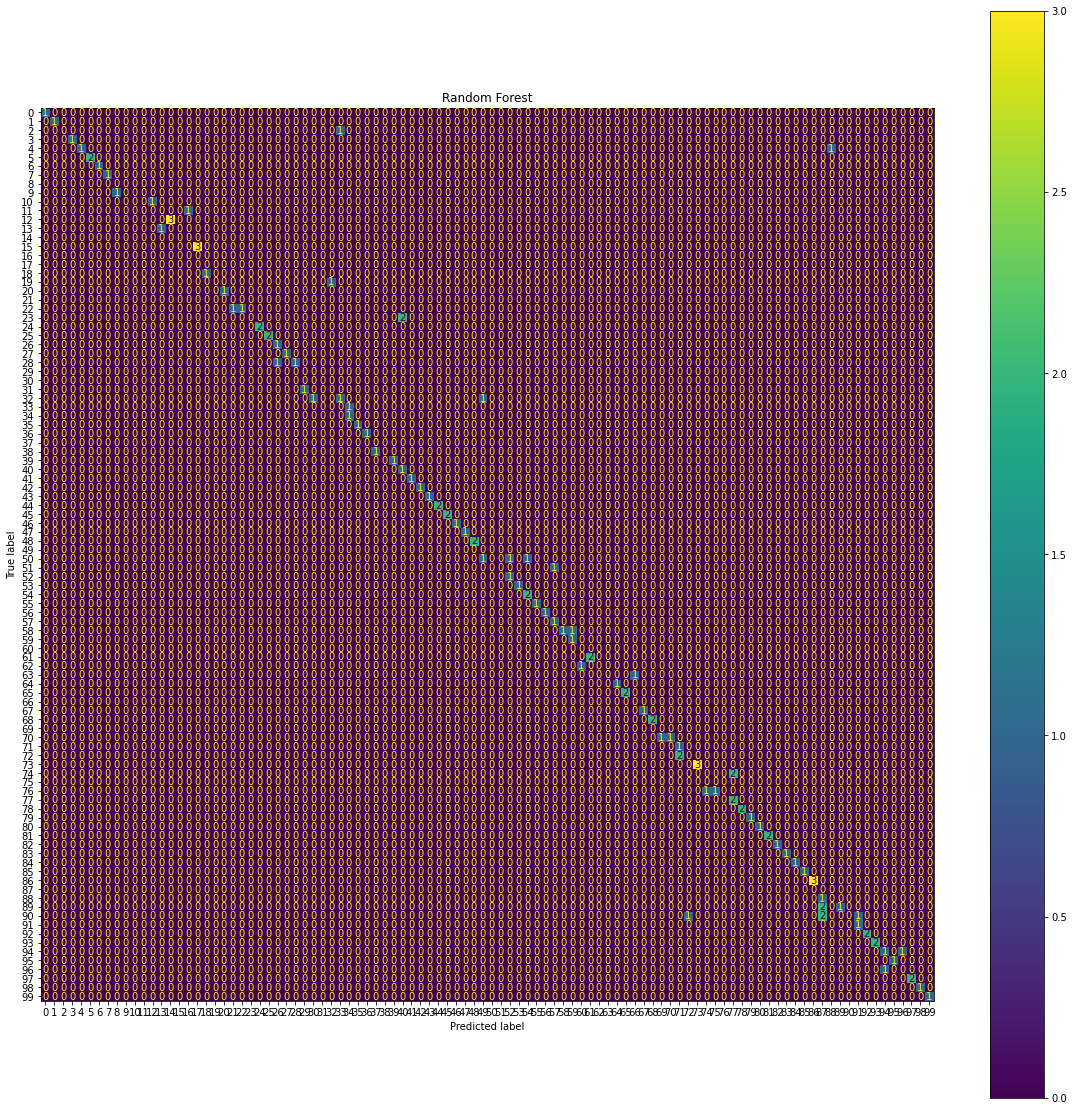

--------------------------------------------------------------
ExtraTreesClassifier
              precision    recall  f1-score   support

         300       1.00      1.00      1.00         2
         301       1.00      1.00      1.00         2
         302       1.00      1.00      1.00         2
         303       1.00      1.00      1.00         1
        304B       1.00      1.00      1.00         2
         307       1.00      1.00      1.00         1
         310       1.00      1.00      1.00         3
         319       1.00      1.00      1.00         1
         321       1.00      1.00      1.00         3
         322       1.00      1.00      1.00         2
         324       1.00      1.00      1.00         1
         325       1.00      1.00      1.00         1
         326       1.00      1.00      1.00         1
         327       1.00      1.00      1.00         1
         328       1.00      1.00      1.00         1
         330       1.00      1.00      1.00        

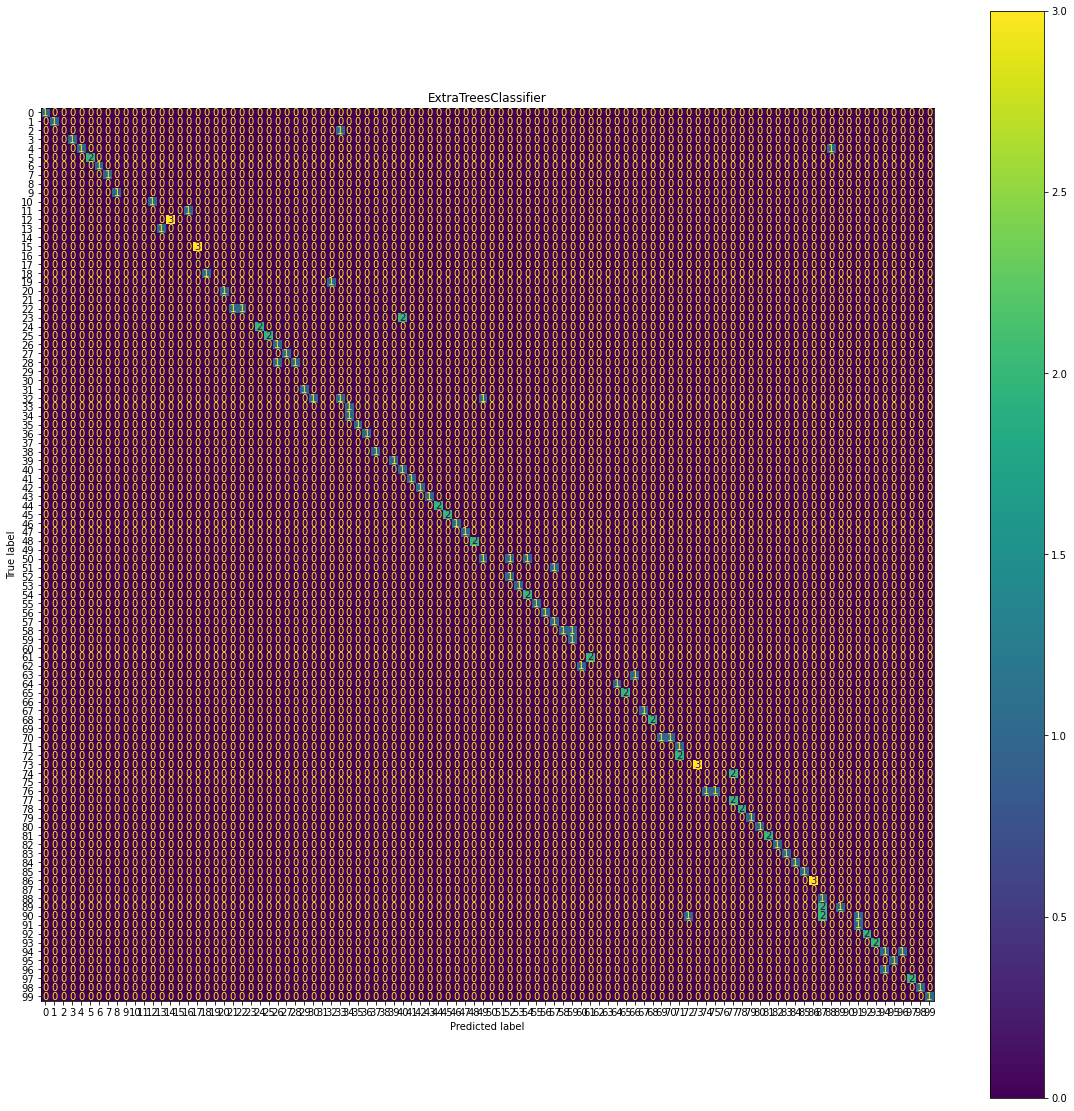

--------------------------------------------------------------


In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")
names = ["K-Nearest Neighbors", "Liner SVM",
         "Decision Tree", "Random Forest",
         "ExtraTreesClassifier"]
classifiers = [
    KNeighborsClassifier(),
    LinearSVC(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    ExtraTreesClassifier()]
clfF=[]
for name, clf in zip(names, classifiers):
    # Perform classification 
    model = clf
    model.fit(data_vect,labels)
    y_pred = model.predict(X_test)
    print(name)
    print(classification_report(y_test, y_pred))    
    cmp=ConfusionMatrixDisplay(confusion_matrix=cmt)
    fig, ax = plt.subplots(figsize=(20,20))
    cmp.plot(ax=ax)
    plt.title(name)
    plt.show()
    print('--------------------------------------------------------------')
    clfF.append(model)

In [57]:
clfF

[KNeighborsClassifier(),
 LinearSVC(),
 DecisionTreeClassifier(),
 RandomForestClassifier(),
 ExtraTreesClassifier()]

In [58]:
import pickle
import bz2
sfile1 = bz2.BZ2File("All Model", 'w')
pickle.dump(clfF, sfile1) 
sfile2 = bz2.BZ2File("All Vector", 'w')
pickle.dump(vectorizer, sfile2) 